# Vending Machine Inventory Analysis

## Business Objective

Analyze inventory demand, replenishment activity, and product performance to improve inventory planning, optimize restocking operations, and forecast future demand.

## Data Understanding

Review dataset structure, column definitions, data types, and data quality prior to analysis.

**Inventory Dataset**
- 38,982 records
- 6 columns
- Tracks SKU demand across vending machines

**Restock Dataset**
- 722 records
- 5 columns
- Tracks replenishment activity and restocking costs

Data quality review identified no missing values in either dataset. Date fields were successfully converted for time-series analysis and forecasting.

## Data Cleaning

Prepare date fields, validate data quality, and ensure datasets are suitable for analysis.

## Data Analysis

Evaluate demand trends, device utilization, replenishment activity, restocking costs, and SKU performance to identify operational insights.

In [1]:
import pandas as pd

### Dataset Overview

Two datasets are used in this analysis:

**Inventory Turnover**
- Tracks product demand across vending machines
- Includes SKU, dispense date, device ID, and quantity dispensed

**Restock Data**
- Tracks replenishment activity
- Includes device ID, restock date, order ID, and restocking costs

In [4]:
inventory = pd.read_csv(r"C:\Users\drall\OneDrive\Desktop\analytics_engineer_portfolio\02_vending_analysis_project\Inventory_Turnover.csv")

In [5]:
inventory.head()

,sku,dispense_date,device_id,package_qty,qty_dispensed
0,05d98e5c2603bf927952aa3eb74d1fc3,22-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20
1,05d98e5c2603bf927952aa3eb74d1fc3,21-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,9
2,05d98e5c2603bf927952aa3eb74d1fc3,20-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,15
3,05d98e5c2603bf927952aa3eb74d1fc3,19-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,13
4,05d98e5c2603bf927952aa3eb74d1fc3,18-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,24


In [6]:
inventory.shape

(38982, 5)

In [7]:
restock = pd.read_csv(r"C:\Users\drall\OneDrive\Desktop\analytics_engineer_portfolio\02_vending_analysis_project\Restock_data.csv")

In [8]:
restock.head()

,device_id,global_order_id,restock_date,currency_code,total
0,device_0749c361d8ac7047c2f98fbcb2eadd16,05f46e618fbb92810f9eed53e2f55a73,2023-12-04 18:09:57.986537,USD,359.58
1,device_65ae7ea424c57d46ac409256fe359349,9af13752287b4011aa8c67572db4fe4a,2023-11-06 15:19:35.630031,USD,344.69
2,device_af645ebf4c96eb6e430529a2a9913686,c444a49754db44199ee59310ab427e53,2023-05-15 12:10:01.056616,USD,338.48
3,device_0749c361d8ac7047c2f98fbcb2eadd16,08dd5a4c6a1d406a3d7f5f2c9f63e752,2024-01-24 15:04:48.844780,USD,43.08
4,device_0749c361d8ac7047c2f98fbcb2eadd16,9bfc4033193d4556360b4729fe25e75c,2023-06-30 14:29:48.834370,USD,177.15


In [9]:
restock.shape

(722, 5)

In [43]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38982 entries, 0 to 38981
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sku            38982 non-null  object        
 1   dispense_date  38982 non-null  datetime64[ns]
 2   device_id      38982 non-null  object        
 3   package_qty    38982 non-null  int64         
 4   qty_dispensed  38982 non-null  int64         
 5   month          38982 non-null  period[M]     
dtypes: datetime64[ns](1), int64(2), object(2), period[M](1)
memory usage: 1.8+ MB


In [11]:
restock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   device_id        722 non-null    object 
 1   global_order_id  722 non-null    object 
 2   restock_date     722 non-null    object 
 3   currency_code    722 non-null    object 
 4   total            722 non-null    float64
dtypes: float64(1), object(4)
memory usage: 28.3+ KB


In [13]:
restock['restock_date'] = pd.to_datetime(restock['restock_date'])

In [14]:
restock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   device_id        722 non-null    object        
 1   global_order_id  722 non-null    object        
 2   restock_date     722 non-null    datetime64[ns]
 3   currency_code    722 non-null    object        
 4   total            722 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 28.3+ KB


Converted restock_date from an object datatype to a datetime datatype to enable time-based analysis such as monthly trends, seasonality analysis, and date aggregations.

In [15]:
restock['global_order_id'].nunique()

722

In [16]:
restock.shape

(722, 5)

Last two commands prove global_order_id is our unique key. 

In [17]:
inventory.duplicated().sum()

np.int64(0)

In [18]:
restock.duplicated().sum()

np.int64(0)

Initial data quality checks identified no duplicate records in either dataset. The restock dataset contained no missing values. The restock_date field was converted from object to datetime format to support time-series analysis and date-based aggregations.

In [19]:
inventory['dispense_date'] = pd.to_datetime(
    inventory['dispense_date'],
    format='%d-%m-%Y'
)

In [20]:
inventory.columns

Index(['sku', 'dispense_date', 'device_id', 'package_qty', 'qty_dispensed'], dtype='object')

In [21]:
inventory.head()

,sku,dispense_date,device_id,package_qty,qty_dispensed
0,05d98e5c2603bf927952aa3eb74d1fc3,2024-02-22,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20
1,05d98e5c2603bf927952aa3eb74d1fc3,2024-02-21,device_0749c361d8ac7047c2f98fbcb2eadd16,1,9
2,05d98e5c2603bf927952aa3eb74d1fc3,2024-02-20,device_0749c361d8ac7047c2f98fbcb2eadd16,1,15
3,05d98e5c2603bf927952aa3eb74d1fc3,2024-02-19,device_0749c361d8ac7047c2f98fbcb2eadd16,1,13
4,05d98e5c2603bf927952aa3eb74d1fc3,2024-02-18,device_0749c361d8ac7047c2f98fbcb2eadd16,1,24


In [25]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38982 entries, 0 to 38981
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sku            38982 non-null  object        
 1   dispense_date  38982 non-null  datetime64[ns]
 2   device_id      38982 non-null  object        
 3   package_qty    38982 non-null  int64         
 4   qty_dispensed  38982 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 1.5+ MB


In [26]:
inventory['month'] = inventory['dispense_date'].dt.to_period('M')

monthly_demand = (
    inventory.groupby('month')['qty_dispensed']
    .sum()
    .reset_index()
)

monthly_demand

,month,qty_dispensed
0,2022-02,2947
1,2022-03,15283
2,2022-04,14378
3,2022-05,14793
4,2022-06,15607
5,2022-07,17530
6,2022-08,18077
7,2022-09,15119
8,2022-10,17266
9,2022-11,19581


Monthly demand was aggregated to identify long-term demand trends and recurring seasonal patterns. This dataset will be used to evaluate historical demand behavior and support future demand forecasting.

In [28]:
import matplotlib.pyplot as plt

Monthly demand exhibits a positive long-term trend, suggesting increasing consumption of inventory over time. Periodic fluctuations are visible; additional analysis is required to determine whether these represent true seasonality or normal operational variability. 

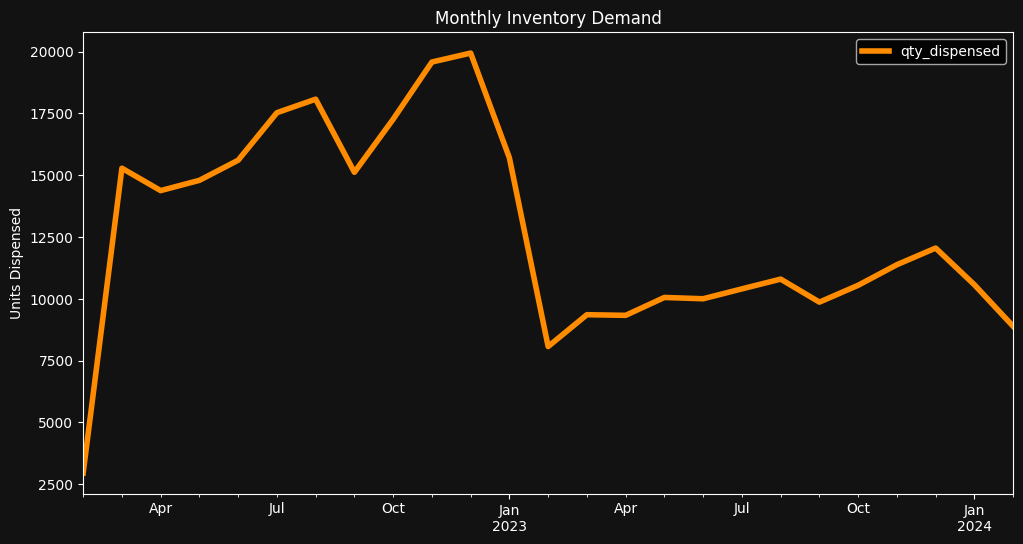

In [76]:
ax = monthly_demand.plot(
    x='month',
    y='qty_dispensed',
    kind='line',
    figsize=(12,6),
    color='#ff8c00',
    linewidth=4,
    title='Monthly Inventory Demand'
)

ax.set_facecolor('#121212')
ax.figure.set_facecolor('#121212')

ax.set_xlabel('')
ax.set_ylabel('Units Dispensed', color='white')

ax.tick_params(colors='white')

legend = ax.get_legend()
if legend:
    plt.setp(legend.get_texts(), color='white')

### Demand Trend Analysis

Monthly demand increased throughout most of 2022, reaching a peak near the end of the year before declining sharply in early 2023. Demand then stabilized throughout 2023 and early 2024 at a lower but relatively consistent level.

The recurring increases and decreases observed across multiple years suggest seasonal demand patterns may influence inventory consumption. Additional historical data would improve forecasting accuracy, but current trends indicate predictable fluctuations that should be considered when planning replenishment schedules.

In [30]:
top_skus = (
    inventory.groupby('sku')['qty_dispensed']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_skus.head(10)

,sku,qty_dispensed
0,b1cfc8c80d03027941b0bce8d2ff3deb,21845
1,be61be55295db1941eaf232ee6288fa7,17273
2,93d664dddeea2dd49decf97035051e92,16395
3,9a154810b166b91ae0c3d0cd84fb7e05,16083
4,da3562c59621dd135d3f0255d3fb66aa,14683
5,ff9575eadeeb732ad8095286dc2bff82,13167
6,690b7d2f4218991b6496be8eb456a943,12829
7,b701576d3b2e8ea055ac68016e01668e,12307
8,05d98e5c2603bf927952aa3eb74d1fc3,12052
9,78baaaf1b752a5358cb6835cf1a7ef8d,10842


### Top SKU Performance

The top 10 SKUs account for a significant portion of total product demand. The highest-performing SKU dispensed 21,845 units, outperforming the second-ranked SKU by a substantial margin.

This concentration of demand suggests that inventory planning should prioritize high-volume products to reduce stockout risk and improve replenishment efficiency. Further analysis should evaluate whether operational factors, customer preferences, or seasonal demand patterns contribute to the top SKU's performance.

In [31]:
device_utilization = (
    inventory.groupby('device_id')['qty_dispensed']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

device_utilization

,device_id,qty_dispensed
0,device_6726f2a054f54836aaabe8c7643286bc,70397
1,device_65ae7ea424c57d46ac409256fe359349,67741
2,device_c287be7e02167387bf9e7eca061ce5b5,61034
3,device_af645ebf4c96eb6e430529a2a9913686,59568
4,device_0749c361d8ac7047c2f98fbcb2eadd16,58788


### Device Utilization

Device utilization was measured by total units dispensed per vending machine. The highest-performing device dispensed 70,397 units, while the remaining top devices showed relatively similar utilization levels.

This suggests demand is distributed across multiple machines rather than concentrated in a single location. Monitoring high-volume devices can help optimize replenishment schedules, reduce stockout risk, and improve inventory availability.

In [32]:
restock_frequency = (
    restock.groupby('device_id')['global_order_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

restock_frequency

,device_id,global_order_id
0,device_c287be7e02167387bf9e7eca061ce5b5,151
1,device_af645ebf4c96eb6e430529a2a9913686,148
2,device_6726f2a054f54836aaabe8c7643286bc,142
3,device_65ae7ea424c57d46ac409256fe359349,142
4,device_0749c361d8ac7047c2f98fbcb2eadd16,139


### Restock Frequency by Device

Restock frequency was measured by counting replenishment orders per device.

The most frequently replenished device received 151 restock orders, while the top five devices ranged from 139 to 151 orders. The relatively small difference between devices suggests replenishment activity is distributed fairly evenly across the vending network.

When compared with device utilization, replenishment frequency does not perfectly align with demand. This indicates that factors such as machine capacity, product mix, inventory thresholds, or operational policies may influence restocking schedules in addition to consumption levels.

In [33]:
restock_spend = (
    restock.groupby('device_id')['total']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

restock_spend

,device_id,total
0,device_af645ebf4c96eb6e430529a2a9913686,44832.09
1,device_6726f2a054f54836aaabe8c7643286bc,41318.50
2,device_65ae7ea424c57d46ac409256fe359349,40205.51
3,device_c287be7e02167387bf9e7eca061ce5b5,37772.40
4,device_0749c361d8ac7047c2f98fbcb2eadd16,32624.63


### Restock Spend by Device

Restock spend was calculated by summing replenishment costs for each vending machine.

The highest-spend device incurred $44,832 in replenishment costs, while the top five devices ranged from approximately $32,625 to $44,832. Spending rankings differed from both utilization and restock frequency rankings.

This suggests replenishment costs are influenced by factors beyond demand alone, including product mix, inventory pricing, machine capacity, and replenishment strategy. High-spend devices may warrant additional monitoring to identify opportunities for cost optimization.

In [34]:
top_skus = (
    inventory.groupby('sku')['qty_dispensed']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top_skus.head(10)

,sku,qty_dispensed
0,b1cfc8c80d03027941b0bce8d2ff3deb,21845
1,be61be55295db1941eaf232ee6288fa7,17273
2,93d664dddeea2dd49decf97035051e92,16395
3,9a154810b166b91ae0c3d0cd84fb7e05,16083
4,da3562c59621dd135d3f0255d3fb66aa,14683
5,ff9575eadeeb732ad8095286dc2bff82,13167
6,690b7d2f4218991b6496be8eb456a943,12829
7,b701576d3b2e8ea055ac68016e01668e,12307
8,05d98e5c2603bf927952aa3eb74d1fc3,12052
9,78baaaf1b752a5358cb6835cf1a7ef8d,10842


### Top SKU Performance

Demand is concentrated among a relatively small number of products.

The highest-performing SKU dispensed 21,845 units, exceeding the second-ranked SKU by 4,572 units. This gap is substantially larger than the differences observed among the remaining top-performing SKUs, indicating a clear market leader within the product catalog.

The concentration of demand among a limited number of products suggests that inventory planning and replenishment strategies should prioritize high-performing SKUs. Maintaining adequate stock levels for these products may reduce stockout risk and improve overall customer satisfaction.

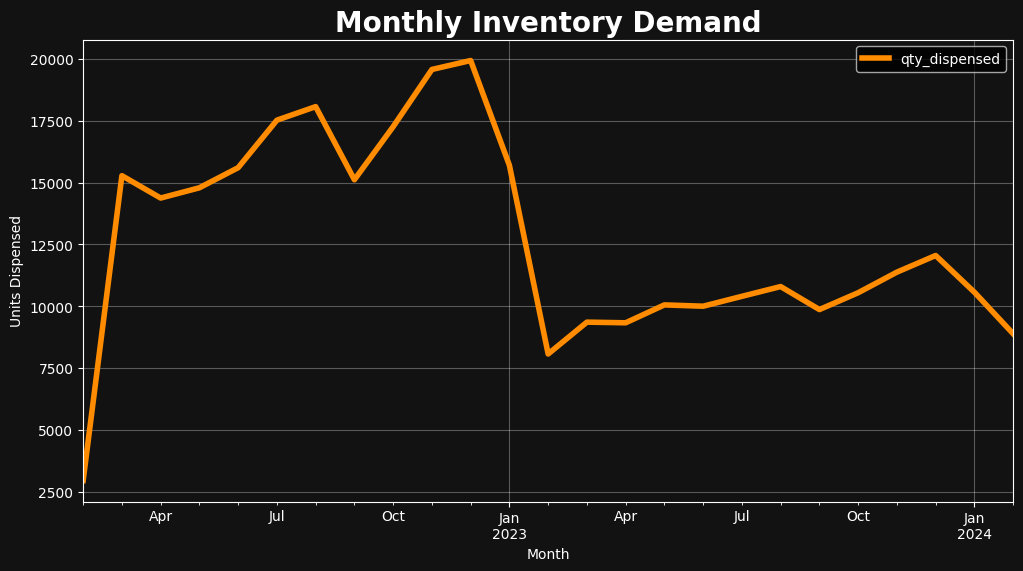

In [47]:
plt.style.use('dark_background')

ax = monthly_demand.plot(
    x='month',
    y='qty_dispensed',
    kind='line',
    figsize=(12,6),
    color='#ff8C00',
    linewidth=4,
    title='Monthly Inventory Demand'
)

ax.set_title(
    'Monthly Inventory Demand',
    fontsize=20,
    fontweight='bold',
    color='white'
)

ax.set_facecolor('#121212')
ax.figure.set_facecolor('#121212')

ax.set_xlabel('Month', color='white')
ax.set_ylabel('Units Dispensed', color='white')

ax.tick_params(colors='white')

plt.grid(alpha=0.3)

legend = ax.get_legend()
if legend:
    plt.setp(legend.get_texts(), color='white')

plt.show()

Text(0.5, 0, '')

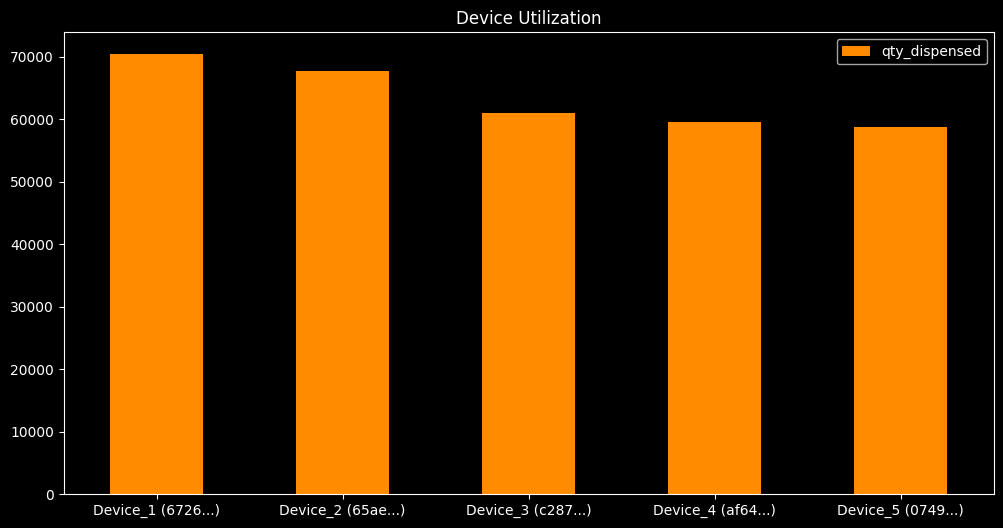

In [53]:
device_utilization['device_label'] = [
    'Device_1 (6726...)',
    'Device_2 (65ae...)',
    'Device_3 (c287...)',
    'Device_4 (af64...)',
    'Device_5 (0749...)'
]
ax = device_utilization.plot(
    x='device_label',
    y='qty_dispensed',
    kind='bar',
    figsize=(12,6),
    color='#ff8c00',
    title='Device Utilization'
)

plt.xticks(rotation=0)

ax.set_xlabel('')

Device utilization is relatively balanced across all five machines. The highest-utilization device dispensed approximately 11.6k more units than the lowest-utilization device, but no machine demonstrates disproportionate demand. This suggests inventory consumption is distributed consistently across the vending network.

Text(0.5, 0, '')

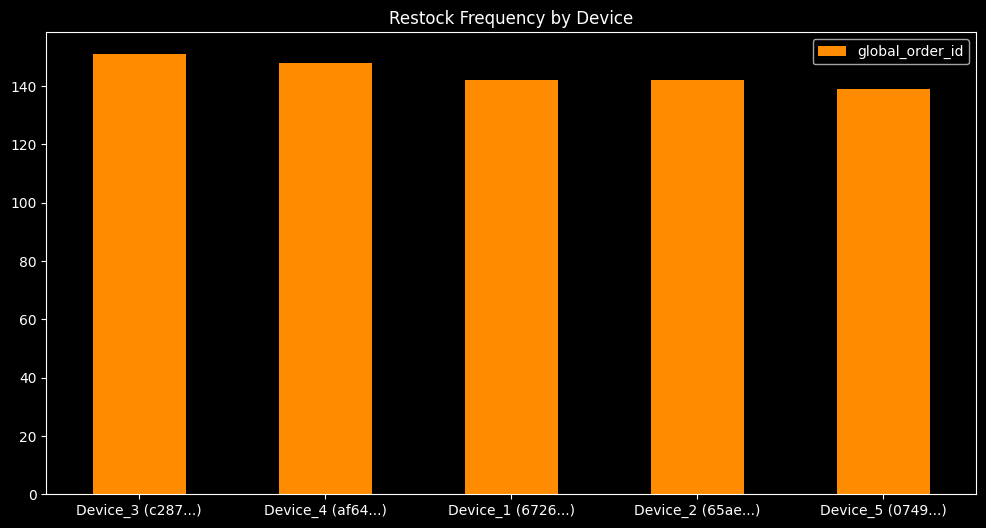

In [57]:
restock_frequency['device_label'] = [
    'Device_3 (c287...)',
    'Device_4 (af64...)',
    'Device_1 (6726...)',
    'Device_2 (65ae...)',
    'Device_5 (0749...)'
]
ax=restock_frequency.plot(
    x='device_label',
    y='global_order_id',
    kind='bar',
    figsize=(12,6),
    color='#ff8c00',
    title='Restock Frequency by Device'
)

plt.xticks(rotation=0)

ax.set_xlabel('')

Restock frequency is remarkably consistent across all five devices, ranging from approximately 139 to 151 replenishment events.

The small variation suggests inventory consumption patterns are broadly similar across devices, with no machine requiring substantially more frequent restocking than the others.

This consistency may indicate balanced customer demand distribution and effective inventory management across locations.

Text(0.5, 0, '')

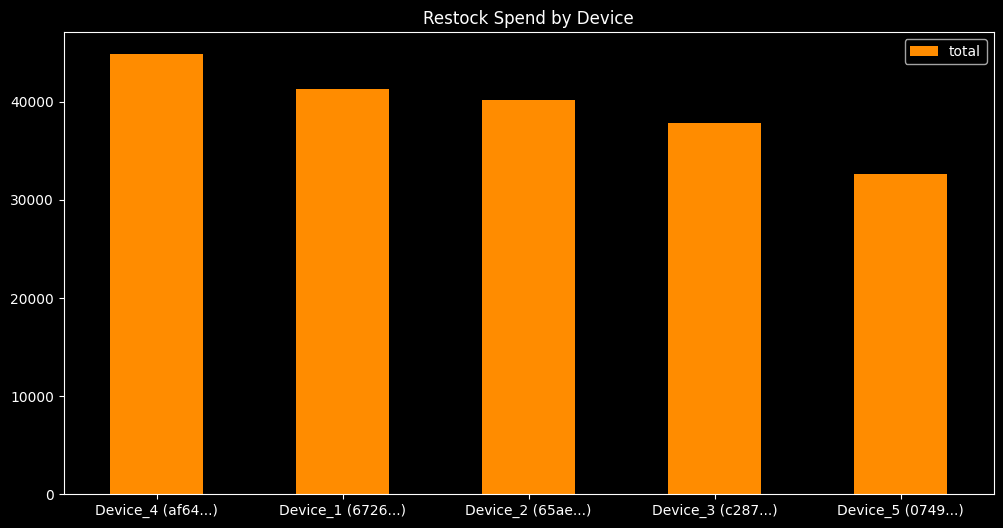

In [65]:
restock_spend['device_label'] = [
    'Device_4 (af64...)',
    'Device_1 (6726...)',
    'Device_2 (65ae...)',
    'Device_3 (c287...)',
    'Device_5 (0749...)'
]

ax=restock_spend.plot (
    x='device_label',
    y='total',
    kind='bar',
    figsize=(12,6),
    color='#ff8c00',
    title='Restock Spend by Device'
)

plt.xticks(rotation=0)

ax.set_xlabel('')

Restock spending varies more noticeably across devices than restock frequency.

While replenishment events occur at relatively similar rates across all five devices, total spending differs substantially. The highest-spend device incurred approximately 44.8k USD in replenishment costs compared to roughly 32.6k USD for the lowest-spend device.

This suggests that differences in product mix, unit costs, or replenishment quantities may be driving spending patterns rather than replenishment frequency alone.

Text(0.5, 0, '')

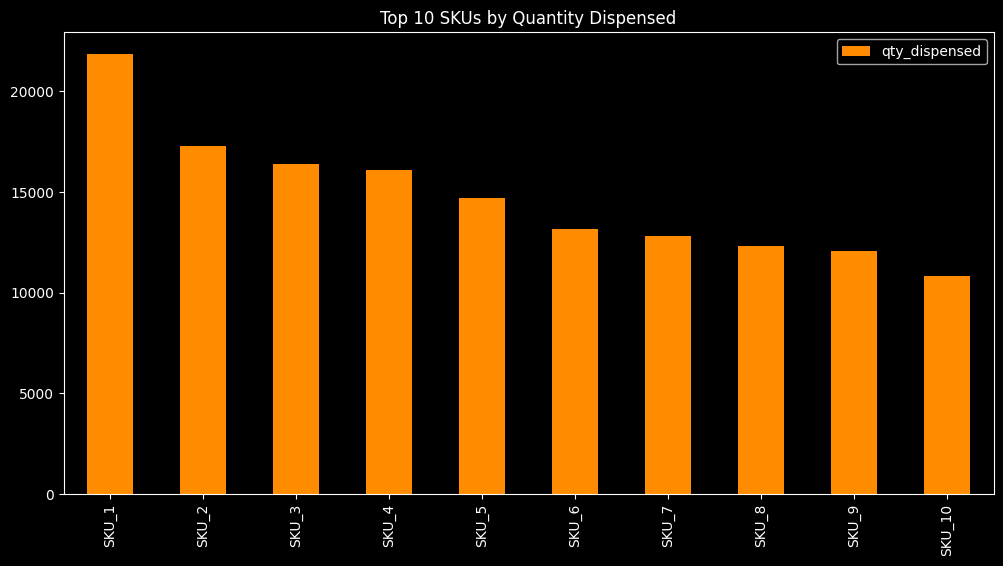

In [74]:
top_10_skus['sku_label'] = [
    'SKU_1',
    'SKU_2',
    'SKU_3',
    'SKU_4',
    'SKU_5',
    'SKU_6',
    'SKU_7',
    'SKU_8',
    'SKU_9',
    'SKU_10'
]



ax = top_10_skus.plot(
    x='sku_label',
    y='qty_dispensed',
    kind='bar',
    figsize=(12,6),
    color='#ff8c00',
    title='Top 10 SKUs by Quantity Dispensed'
)

ax.set_xlabel('')

Inventory demand generally trends upward over time despite periodic fluctuations.

Device utilization is relatively balanced across machines, with no single device overwhelmingly dominating demand.

Restock frequency is also balanced, but does not perfectly align with utilization, suggesting operational factors beyond raw demand influence replenishment schedules.

Restock spend varies more than frequency, indicating some devices are more expensive to replenish despite similar usage patterns.

Product demand is concentrated among a relatively small number of SKUs, with the highest-volume SKU dispensing roughly twice the quantity of the tenth-ranked SKU.

Future analysis could investigate whether seasonal fluctuations are driven by a small number of high-performing SKUs driving replenishment frequency and operational costs.

## Demand Forecast

Demand has generally increased throughout the observed period despite periodic fluctuations. Historical patterns suggest demand may continue to increase in future months, particularly following observed February-to-March growth across multiple years.

Given the limited historical data available, this forecast should be considered directional rather than predictive. Additional years of data would improve confidence in identifying seasonality and long-term demand trends.

Recommendation:
Maintain sufficient inventory levels for top-performing SKUs and monitor demand changes monthly to refine future forecasts.

## Recommendations

1. Monitor top-performing SKUs closely, as demand is concentrated among a small number of products.

2. Review replenishment schedules for devices with high restock frequency but moderate utilization to identify operational inefficiencies.

3. Continue tracking monthly demand trends to validate potential seasonality patterns.

4. Consider expanding inventory planning efforts around top-demand products to reduce stockout risk.

5. Investigate whether seasonal demand changes are driven by specific SKUs or broader customer purchasing behavior.

## Executive Summary

This analysis examined inventory demand, device utilization, replenishment activity, and product performance across the vending machine network.

Key findings include:

- Overall demand increased throughout the observed period despite periodic fluctuations.
- Device utilization was relatively balanced across machines.
- Restock frequency and utilization were not perfectly aligned, suggesting operational factors influence replenishment activity.
- Replenishment spending varied by device despite similar utilization patterns.
- Demand was concentrated among a small number of high-performing SKUs, with the top SKU significantly outperforming the rest of the catalog.

These findings support improved inventory planning, replenishment optimization, and future demand forecasting efforts.